# Sales Forecasting – Improved Pipeline
**What changed vs. the original notebook**
1. The last week (2019-01-06) contains **one day** of data – it is dropped, otherwise the test set contains a fake "drop" in sales.
2. Every feature is shifted by the forecast horizon `H`, so the same code is valid for 1-week-ahead *and* multi-week-ahead forecasting (no leakage).
3. More features: more lags/rolling windows, EWM, weeks-since-last-sale, cumulative sales, average price, online share, global demand level.
4. Count objective (`poisson`) instead of squared error – the target is a sparse count (≈95% zeros).
5. `article_id` and `year` removed as numeric features (an ID is not a quantity; `year` is constant).
6. The "sold / not sold" threshold is **tuned on a validation period** instead of fixed at 0.5 (that is why recall was 3.8%).
7. Extra metrics that make sense for sparse demand (Poisson deviance, AUC, PR-AUC, top-K precision, aggregated accuracy).

In [1]:
import pandas as pd, numpy as np, warnings, os
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score, roc_auc_score,
    average_precision_score, f1_score, precision_score, recall_score, accuracy_score, mean_poisson_deviance)

# Colab: from google.colab import drive; drive.mount('/content/drive')
DATA_DIR = '/content/drive/MyDrive/Forcasting/' if os.path.exists('/content/drive') else '/mnt/user-data/uploads/'
H = 1          # forecast horizon in weeks (try 4 for a 4-week-ahead forecast)
TEST_WEEKS = 8

## 1. Load data & build the weekly product panel

In [2]:
transactions = pd.read_csv(DATA_DIR+'transactions_forecasting.csv', parse_dates=['t_dat'])

# Last week only has Dec-31 (1 day) -> incomplete week, remove it
transactions = transactions[transactions['t_dat'] < '2018-12-31'].copy()
transactions['week_start'] = transactions['t_dat'].dt.to_period('W-SUN').dt.start_time

weeks    = pd.date_range(transactions.week_start.min(), transactions.week_start.max(), freq='7D')
articles = transactions.article_id.unique()
panel = pd.MultiIndex.from_product([weeks, articles], names=['week_start','article_id']).to_frame(index=False)

g = transactions.groupby(['week_start','article_id']).agg(
        y=('price','size'), rev=('price','sum'),
        online=('sales_channel_id', lambda s:(s==1).sum()),
        pmean=('price','mean')).reset_index()
p = panel.merge(g, on=['week_start','article_id'], how='left')
for c in ['y','rev','online']: p[c] = p[c].fillna(0)
p = p.sort_values(['article_id','week_start']).reset_index(drop=True)
print(p.shape, '| mean weekly sales per article: %.3f | share of zeros: %.1f%%' % (p.y.mean(), (p.y==0).mean()*100))

(385060, 6) | mean weekly sales per article: 0.052 | share of zeros: 95.2%


## 2. Feature engineering (leak-free for any horizon `H`)
Everything is computed from data that is available **H weeks before** the week being predicted.

In [3]:
def build_features(p, H=1):
    p = p.copy(); G = p.groupby('article_id')
    for k in [1,2,3,4,8]:
        p[f'lag_{k}'] = G['y'].shift(k+H-1)
    base = G['y'].shift(H); gb = base.groupby(p.article_id)
    for w in [4,8,12,26]:
        p[f'roll_{w}'] = gb.transform(lambda x: x.rolling(w, min_periods=1).mean())
    p['roll_4_max'] = gb.transform(lambda x: x.rolling(4, min_periods=1).max())
    p['ewm_03']     = gb.transform(lambda x: x.ewm(alpha=.3).mean())
    p['cum_sales']  = gb.transform(lambda x: x.fillna(0).cumsum())
    p['ever']       = (p.cum_sales > 0).astype(int)
    last = p.week_start.where(base.fillna(0) > 0).groupby(p.article_id).ffill()
    p['since_last'] = ((p.week_start - last).dt.days/7).fillna(99)
    p['rev_cum']    = p.groupby('article_id')['rev'].transform(lambda x: x.shift(H).fillna(0).cumsum())
    p['price_mean'] = p.groupby('article_id')['pmean'].transform(lambda x: x.shift(H).ffill())
    p['online_share'] = (p.groupby('article_id')['online'].transform(lambda x: x.shift(H).fillna(0).cumsum())
                         / p.cum_sales.replace(0, np.nan))
    # global demand level (captures the pre-Christmas rise without hard-coding dates)
    tot = p.groupby('week_start').y.sum().shift(H)
    p['tot_lag']   = p.week_start.map(tot)
    p['tot_roll4'] = p.week_start.map(tot.rolling(4, min_periods=1).mean())
    p['sin_w'] = np.sin(2*np.pi*p.week_start.dt.isocalendar().week.astype(int)/52)
    p['cos_w'] = np.cos(2*np.pi*p.week_start.dt.isocalendar().week.astype(int)/52)
    return p

d = build_features(p, H)
NON_FEATURES = ['week_start','y','rev','online','pmean','article_id']
feats = [c for c in d.columns if c not in NON_FEATURES]
print(len(feats), 'features:', feats)

21 features: ['lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_8', 'roll_4', 'roll_8', 'roll_12', 'roll_26', 'roll_4_max', 'ewm_03', 'cum_sales', 'ever', 'since_last', 'rev_cum', 'price_mean', 'online_share', 'tot_lag', 'tot_roll4', 'sin_w', 'cos_w']


## 3. Time-based split
* **Test**: last 8 complete weeks. **Validation** (used only to pick the threshold): the 8 weeks before it.
* For `H>1` a gap of `H-1` weeks is left so no training target overlaps the test period.

In [4]:
TEST0 = weeks[-TEST_WEEKS]; VAL0 = weeks[-2*TEST_WEEKS]; gap = pd.Timedelta(weeks=H-1)
base = d[d.week_start >= weeks[4]]                      # keep early rows (min_periods handles short history)
tr  = base[base.week_start < TEST0 - gap]
te  = base[base.week_start >= TEST0].copy()
trv = base[base.week_start < VAL0 - gap]
va  = base[(base.week_start >= VAL0) & (base.week_start < TEST0 - gap)]
print('train', tr.shape, '| test', te.shape, '| test weeks', te.week_start.min().date(), '->', te.week_start.max().date())

train (296200, 27) | test (59240, 27) | test weeks 2018-11-05 -> 2018-12-24


## 4. Evaluation helper & baselines

In [5]:
def score(y, pred, name):
    pred = np.asarray(pred)
    return dict(model=name,
                MAE=mean_absolute_error(y, pred), RMSE=mean_squared_error(y, pred)**.5, R2=r2_score(y, pred),
                PoisDev=mean_poisson_deviance(y, np.clip(pred, 1e-6, None)),
                AUC=roc_auc_score(y>0, pred), PR_AUC=average_precision_score(y>0, pred))

results = [score(te.y, te.roll_4,  'Naive: rolling-4 mean'),
           score(te.y, te.roll_12, 'Naive: rolling-12 mean')]

# Your original setup (squared-error, same features, article_id kept) on the corrected split
orig_feats = ['article_id','lag_1','lag_2','lag_4','lag_8','roll_4','roll_8','roll_12']
m0 = LGBMRegressor(n_estimators=300, max_depth=7, learning_rate=.05, random_state=42, verbose=-1).fit(tr[orig_feats], tr.y)
results.append(score(te.y, m0.predict(te[orig_feats]), 'Original LightGBM (L2)'))

## 5. Improved models

In [6]:
prm = dict(objective='poisson', n_estimators=400, learning_rate=.03, num_leaves=31, min_child_samples=100,
           subsample=.8, subsample_freq=1, colsample_bytree=.8, reg_lambda=5, random_state=42, verbose=-1)
m_lgb = LGBMRegressor(**prm).fit(tr[feats], tr.y)
te['p_lgb'] = m_lgb.predict(te[feats])
results.append(score(te.y, te.p_lgb, 'LightGBM Poisson + new features'))

m_xgb = XGBRegressor(objective='count:poisson', n_estimators=400, learning_rate=.03, max_depth=5,
                     min_child_weight=20, subsample=.8, colsample_bytree=.8, reg_lambda=5, random_state=42,
                     tree_method='hist').fit(tr[feats], tr.y)
te['p_xgb'] = m_xgb.predict(te[feats])
results.append(score(te.y, te.p_xgb, 'XGBoost Poisson + new features'))

te['pred'] = .5*te.p_lgb + .5*te.p_xgb
results.append(score(te.y, te.pred, 'Blend (LGBM + XGB)'))
res = pd.DataFrame(results).set_index('model').round(4); res

,MAE,RMSE,R2,PoisDev,AUC,PR_AUC
model,,,,,,
Naive: rolling-4 mean,0.1097,0.2849,-0.0722,1.2189,0.5702,0.1021
Naive: rolling-12 mean,0.1066,0.2650,0.0720,0.9020,0.5954,0.1321
Original LightGBM (L2),0.1062,0.2612,0.0986,0.3386,0.6199,0.1493
LightGBM Poisson + new features,0.1031,0.2573,0.1253,0.3140,0.7358,0.1923
XGBoost Poisson + new features,0.1032,0.2576,0.1236,0.3126,0.7413,0.1944
Blend (LGBM + XGB),0.1031,0.2574,0.1251,0.3132,0.7385,0.1931


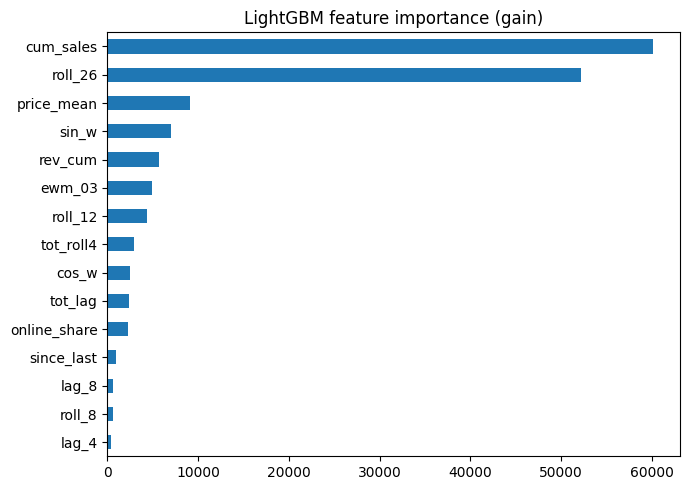

In [7]:
imp = pd.Series(m_lgb.booster_.feature_importance('gain'), index=feats).sort_values()
imp.tail(15).plot.barh(figsize=(7,5), title='LightGBM feature importance (gain)'); plt.tight_layout(); plt.show()

## 6. "Sold / not sold" – threshold tuned on validation (not fixed at 0.5)
Expected sales per article-week are ~0.05, so a prediction above 0.5 is almost never produced – that is why recall was ≈4%.

In [8]:
mv = LGBMRegressor(**prm).fit(trv[feats], trv.y); pv = mv.predict(va[feats])
ths = np.linspace(.02, .6, 59); th = ths[int(np.argmax([f1_score(va.y>0, pv>t) for t in ths]))]
print('Threshold chosen on validation: %.2f' % th)
yb = te.y > 0
rows = []
for name, thr in [('threshold 0.5 (original)', .5), (f'tuned threshold {th:.2f}', th)]:
    pb = te.pred > thr
    rows.append(dict(setting=name, Accuracy=accuracy_score(yb,pb), Precision=precision_score(yb,pb,zero_division=0),
                     Recall=recall_score(yb,pb), F1=f1_score(yb,pb)))
pd.DataFrame(rows).set_index('setting').round(4)

Threshold chosen on validation: 0.12


,Accuracy,Precision,Recall,F1
setting,,,,
threshold 0.5 (original),0.9414,0.5578,0.0400,0.0747
tuned threshold 0.12,0.8980,0.2103,0.2639,0.2341


## 7. Business-level accuracy (where item-level noise averages out)

Weekly total sales  - MAPE: 16.3%
8-week article totals - R2: 0.558 | AUC (will it sell at all?): 0.819
Top-100 weekly picks: 40.2% sell vs 5.9% base rate (6.8x lift)


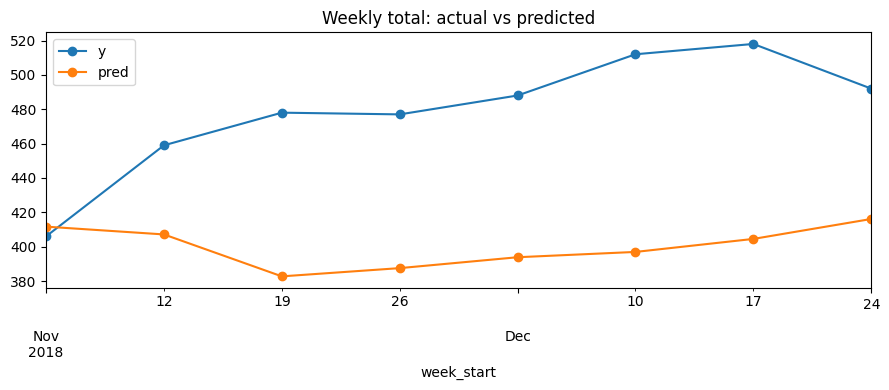

In [9]:
# (a) weekly total demand
wk = te.groupby('week_start')[['y','pred']].sum()
print('Weekly total sales  - MAPE: %.1f%%' % ((abs(wk.y-wk.pred)/wk.y).mean()*100))

# (b) article-level over the whole 8-week test window
ar = te.groupby('article_id')[['y','pred']].sum()
print('8-week article totals - R2: %.3f | AUC (will it sell at all?): %.3f' % (r2_score(ar.y, ar.pred), roc_auc_score(ar.y>0, ar.pred)))

# (c) ranking: if you stock/promote the top-K articles each week, how often do they sell?
hit = np.mean([(g.sort_values('pred', ascending=False).head(100).y > 0).mean() for _, g in te.groupby('week_start')])
print('Top-100 weekly picks: %.1f%% sell vs %.1f%% base rate (%.1fx lift)' % (hit*100, yb.mean()*100, hit/yb.mean()))

ax = wk.plot(figsize=(9,4), marker='o', title='Weekly total: actual vs predicted'); plt.tight_layout(); plt.show()

## 8. Notes on limits of this dataset
* Each article sells **≈2.7 times per year** (median 1) → weekly article-level data is mostly noise; R² at that level has a low ceiling. Use the aggregated / ranking / probability views above for decisions.
* Only ~38% of sold articles exist in `inventory.csv`, so product attributes were not usable (tested: no gain).
* `inventory.sales_count` equals the **full-year** transaction count → it leaks the future; never use it as a feature.
* The article universe is "articles with ≥1 sale in 2018", which already hints at future sales. For production, forecast the live catalogue instead.